In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sms
from datetime import datetime
plt.style.use('dark_background')

In [2]:
df = pd.read_csv(r"./DailyDelhiClimateTrain.csv")
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.set_index('date',inplace=True)
df.sort_index(inplace=True)
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


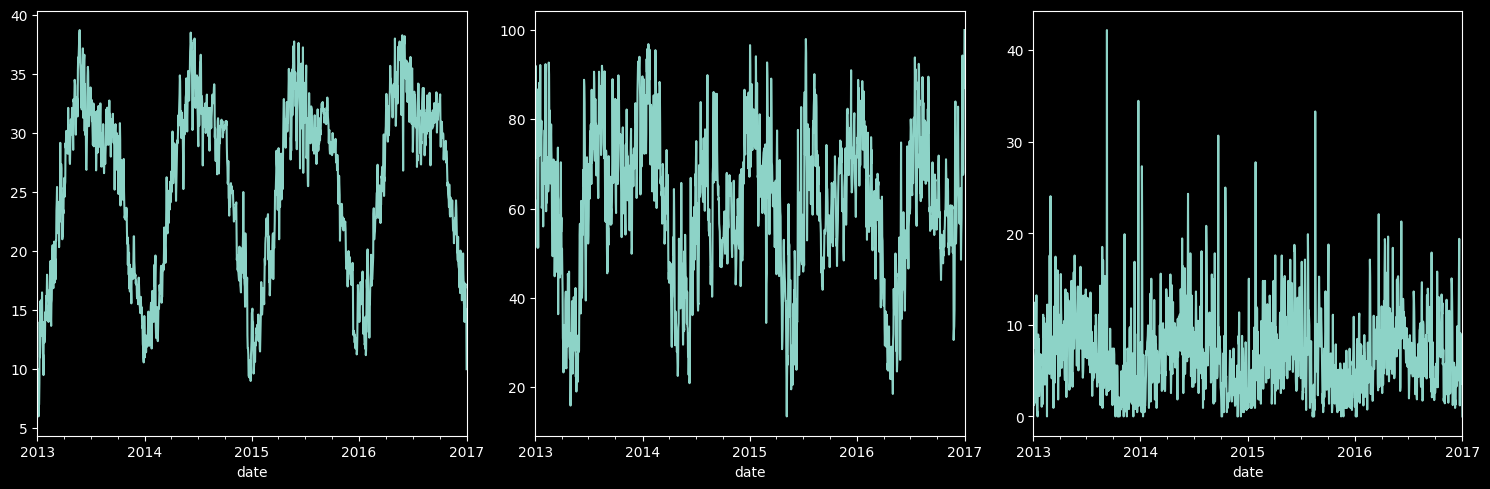

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['meantemp'].plot(ax=axes[0])
df['humidity'].plot(ax=axes[1])
df['wind_speed'].plot(ax=axes[2])
plt.tight_layout()
plt.show()

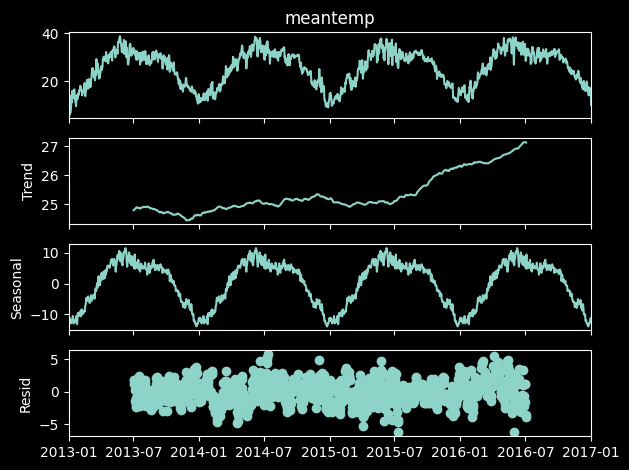

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
temps = seasonal_decompose(df['meantemp'],model='additive',period=365)
temps.plot()
plt.show()

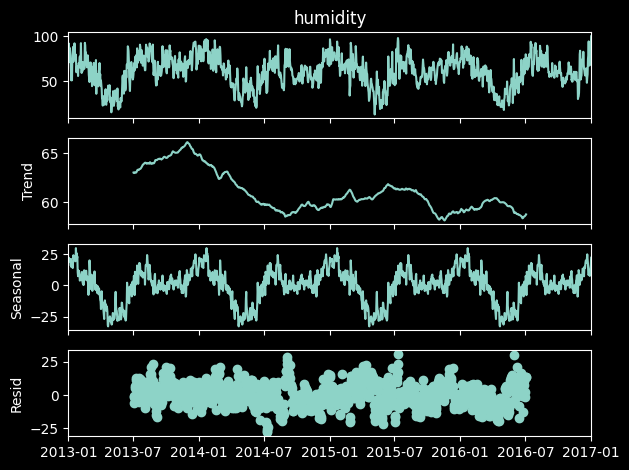

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
humids = seasonal_decompose(df['humidity'],model='additive',period=365)
humids.plot()
plt.show()

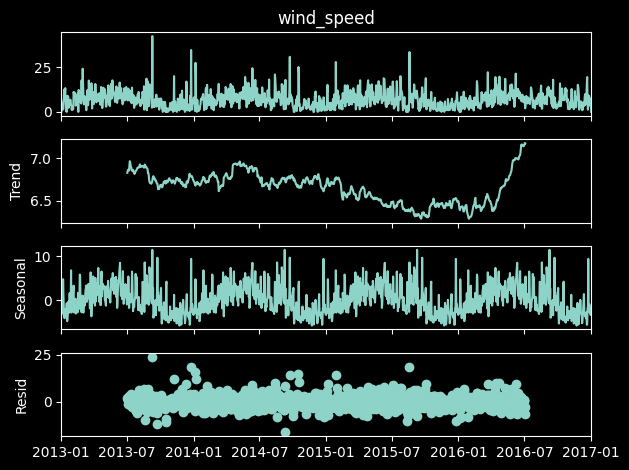

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
winds = seasonal_decompose(df['wind_speed'],model='additive',period=365)
winds.plot()
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller
def check(x):
    r = adfuller(x)
    print(r[1]<0.05)

In [8]:
check(df['meantemp'])
check(df['meantemp'].diff().dropna())
check(df['humidity'].diff().dropna())
check(df['wind_speed'].diff().dropna())

False
True
True
True


In [9]:
df['Stemp']=df['meantemp'].diff(365)
df['Shum'] = df['humidity'].diff(365)
df['Swind']=df['wind_speed'].diff(365)

In [10]:
test = pd.read_csv(r"./DailyDelhiClimateTest.csv")
test['date'] = pd.to_datetime(test['date'], format='%Y-%m-%d')
test.set_index('date',inplace=True)
test.sort_index(inplace=True)

In [11]:
from statsmodels.tsa.api import VAR
from datetime import datetime,timedelta
train = df.copy()
train.dropna(inplace=True)
model = VAR(train[['Stemp','Shum','Swind']]) 
lag_selection = model.select_order(maxlags=20)
print(lag_selection.summary())
optimal_lag = lag_selection.aic
print(optimal_lag)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        10.90       10.91   5.423e+04       10.91
1        9.153      9.208*       9441.       9.174
2        9.118       9.215       9115.      9.155*
3        9.125       9.264       9183.       9.178
4        9.110       9.291       9049.       9.179
5       9.108*       9.330      9025.*       9.192
6        9.116       9.380       9101.       9.216
7        9.121       9.426       9143.       9.236
8        9.125       9.472       9180.       9.256
9        9.132       9.520       9243.       9.279
10       9.125       9.555       9184.       9.288
11       9.134       9.606       9267.       9.313
12       9.136       9.650       9287.       9.331
13       9.143       9.698       9353.       9.354
14       9.154       9.751       9456.       9.380
15       9.155       9.793       9463.       9.397
16       9.151       9.831     

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [12]:
def reversediff(x,y):
    seasonal_period = 365
    forecast_steps = len(x)
    forecast = np.zeros(forecast_steps + seasonal_period)
    forecast[:seasonal_period] = y
    forecast[seasonal_period:] = x + forecast[:forecast_steps]
    reverse_forecast = forecast[seasonal_period:]
    return reverse_forecast

In [13]:
test.shape

(114, 4)

In [14]:
results = model.fit(optimal_lag)
t = train[['Stemp','Shum','Swind']].copy()
f_input = t.iloc[-optimal_lag:].to_numpy()
forecast_values = results.forecast(f_input, steps=114)
test['Ftemp'] = reversediff(forecast_values[:,0],train['meantemp'].iloc[-365:])
test['Fhum'] = reversediff(forecast_values[:,1],train['humidity'].iloc[-365:])
test['Fwind'] = reversediff(forecast_values[:,2],train['wind_speed'].iloc[-365:])
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error as rmse
print("temp error: ",mape(test['meantemp'],test['Ftemp']))
print("humidity error: ",mape(test['humidity'],test['Fhum']))
print("wind error: ",mape(test['wind_speed'],test['Fwind']))

temp error:  0.1466005518797446
humidity error:  0.17587901914511833
wind error:  0.6307337205054392


<Axes: xlabel='date'>

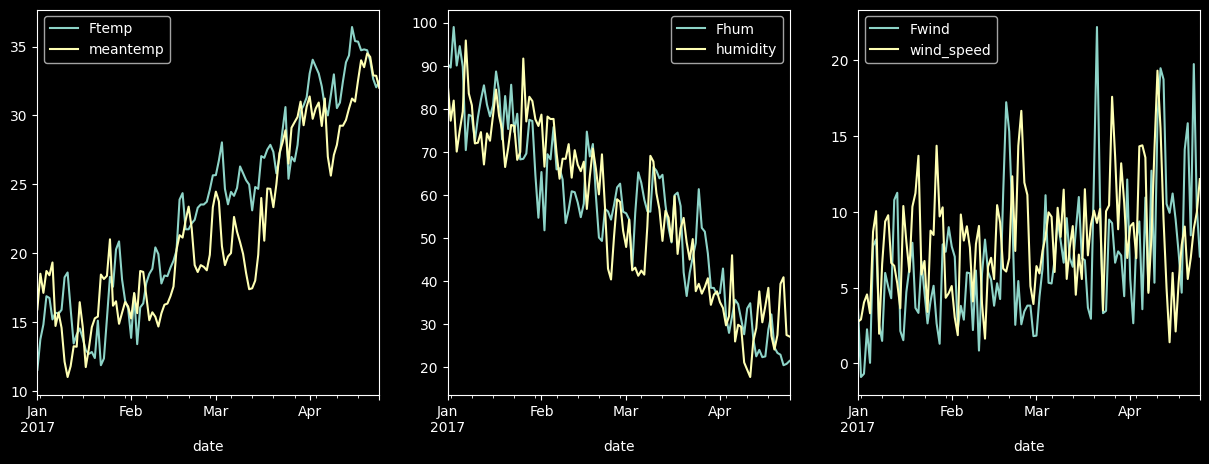

In [15]:
fig,axes = plt.subplots(1,3,figsize=(15, 5))
test[['Ftemp','meantemp']].plot(ax=axes[0])
test[['Fhum','humidity']].plot(ax=axes[1])
test[['Fwind','wind_speed']].plot(ax=axes[2])

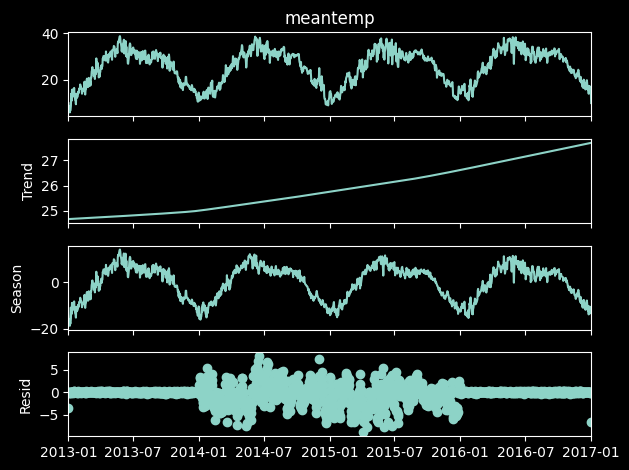

In [16]:
from statsmodels.tsa.seasonal import STL
stl = STL(df['meantemp'], period=365, robust=True)
result = stl.fit()
trend = result.trend
seasonal = result.seasonal
residual = result.resid
result.plot()
plt.show()


<Axes: xlabel='date'>

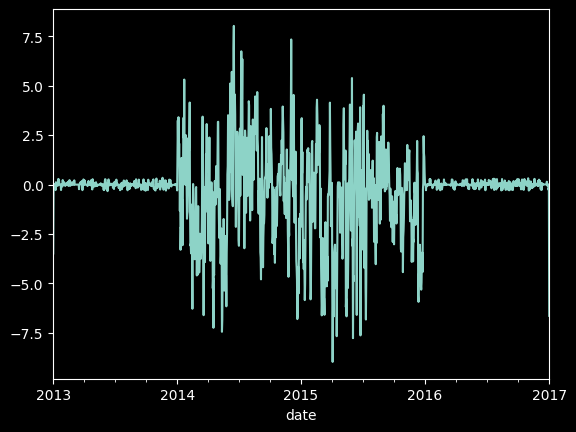

In [17]:
residual.plot()

True


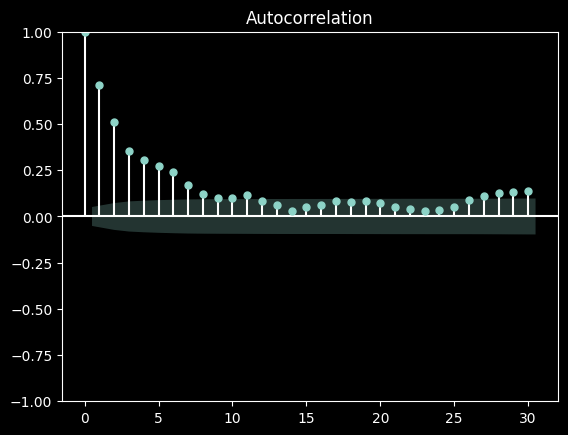

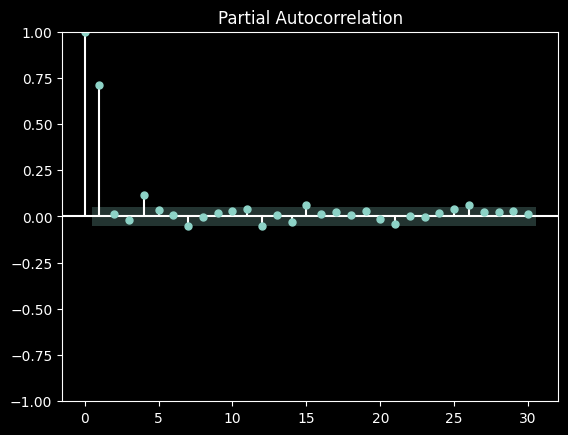

In [18]:
df['temp_res'] = residual
check(df['temp_res'].dropna())
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf = plot_acf(df['temp_res'].dropna(), lags=30)
pacf = plot_pacf(df['temp_res'].dropna(), lags=30)

In [19]:
df['temp_tr'] = trend
df['temp_sea'] = seasonal
def decompose(x):
    stl = STL(x, period=365, robust=True)
    r = stl.fit()
    return r.trend, r.seasonal, r.resid

In [20]:
t,s,r = decompose(df['humidity'])
df['hum_tr']=t
df['hum_sea'] =s
df['hum_res'] = r
t,s,r = decompose(df['wind_speed'])
df['win_tr'] = t
df['win_sea'] = s
df['win_res'] = r

In [21]:
from feature_engine.timeseries.forecasting import LagFeatures, WindowFeatures, ExpandingWindowFeatures
def features(df,val):
    lag_transformer = LagFeatures(variables=[val],periods=[1,2,7,30,365])
    df_lagged = lag_transformer.fit_transform(df)
    rolling_transformer = WindowFeatures(
    variables=[val],
    window=[3,7,30,365],
    functions=['mean', 'std', 'max']
    )
    df_rolling = rolling_transformer.fit_transform(df)
    expanding_transformer = ExpandingWindowFeatures(
    variables=[val],
    functions=['mean', 'std']
    )
    df_expanding = expanding_transformer.fit_transform(df)
    combined_df = pd.concat([df_lagged, df_rolling, df_expanding], axis=1)
    combined_df = combined_df.T.drop_duplicates().T
    return combined_df


In [22]:
df_temp = features(df[['meantemp']],'meantemp')
df_hum = features(df[['humidity']],'humidity')
df_win = features(df[['wind_speed']],'wind_speed')

In [23]:
combined_df = pd.concat([df_temp, df_hum, df_win], axis=1)
combined_df = combined_df.T.drop_duplicates().T
combined_df.columns

Index(['meantemp', 'meantemp_lag_1', 'meantemp_lag_2', 'meantemp_lag_7',
       'meantemp_lag_30', 'meantemp_lag_365', 'meantemp_window_3_mean',
       'meantemp_window_3_std', 'meantemp_window_3_max',
       'meantemp_window_7_mean', 'meantemp_window_7_std',
       'meantemp_window_7_max', 'meantemp_window_30_mean',
       'meantemp_window_30_std', 'meantemp_window_30_max',
       'meantemp_window_365_mean', 'meantemp_window_365_std',
       'meantemp_window_365_max', 'meantemp_expanding_mean',
       'meantemp_expanding_std', 'humidity', 'humidity_lag_1',
       'humidity_lag_2', 'humidity_lag_7', 'humidity_lag_30',
       'humidity_lag_365', 'humidity_window_3_mean', 'humidity_window_3_std',
       'humidity_window_3_max', 'humidity_window_7_mean',
       'humidity_window_7_std', 'humidity_window_7_max',
       'humidity_window_30_mean', 'humidity_window_30_std',
       'humidity_window_30_max', 'humidity_window_365_mean',
       'humidity_window_365_std', 'humidity_window_365_max',

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
X = combined_df.drop(columns=["meantemp", "humidity", "wind_speed"])
Y = combined_df[["meantemp", "humidity", "wind_speed"]]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Multi-output model
model = MultiOutputRegressor(RandomForestRegressor(random_state=42))
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred, multioutput='raw_values')
mae = median_absolute_error(Y_test, Y_pred, multioutput='raw_values')
r2 = r2_score(Y_test, Y_pred, multioutput='raw_values')
print(f"Mean Squared Error for Each Target: {mse}")
print(f"Median error for Each Target: {mape}")
print(f"r2 score for Each Target: {r2}")


Mean Squared Error for Each Target: [ 2.66000947 72.17892779 17.33376875]
Median error for Each Target: <function mean_absolute_percentage_error at 0x000002319CA937E0>
r2 score for Each Target: [0.95052014 0.72448557 0.26638718]


In [25]:
data = df[['meantemp','humidity','wind_speed','meanpressure']]
corr = data.corr(method='spearman')
print(corr)

              meantemp  humidity  wind_speed  meanpressure
meantemp      1.000000 -0.576162    0.372731     -0.869542
humidity     -0.576162  1.000000   -0.420774      0.309705
wind_speed    0.372731 -0.420774    1.000000     -0.342559
meanpressure -0.869542  0.309705   -0.342559      1.000000


In [26]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
X = df_win.drop(columns=['wind_speed'])
Y = combined_df["wind_speed"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Multi-output model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred, )
mae = median_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print(f"Mean Squared Error for Each Target: {mse}")
print(f"Median error for Each Target: {mae}")
print(f"r2 score for Each Target: {r2}")

Mean Squared Error for Each Target: 18.06575569407323
Median error for Each Target: 2.210023494098494
r2 score for Each Target: 0.23540747267656625


<Axes: xlabel='date', ylabel='wind_speed'>

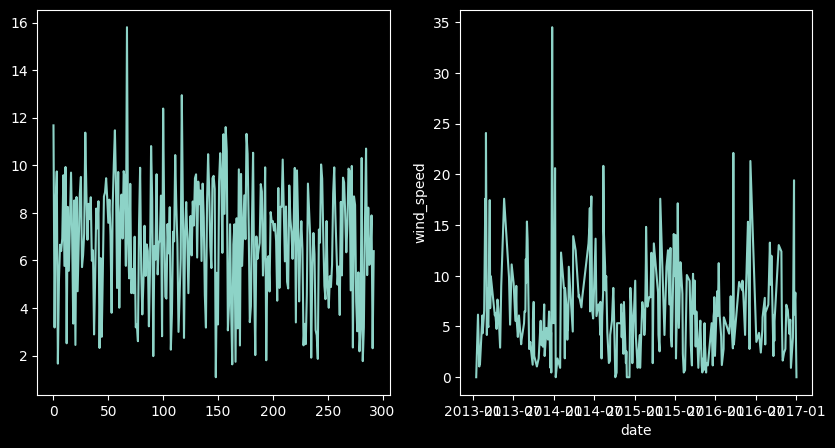

In [27]:
fig,axes = plt.subplots(1,2, figsize=(10,5))
sns.lineplot(Y_pred,ax=axes[0])
sns.lineplot(Y_test,ax=axes[1])

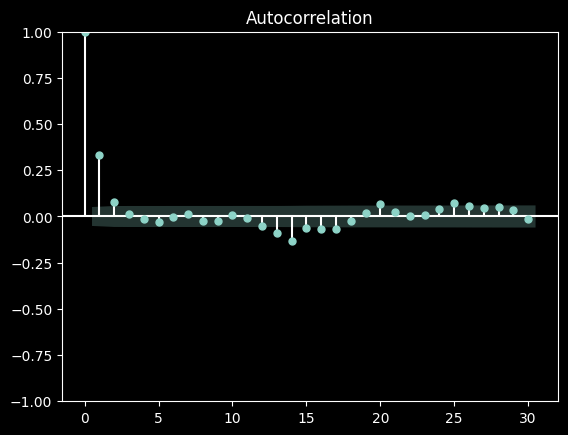

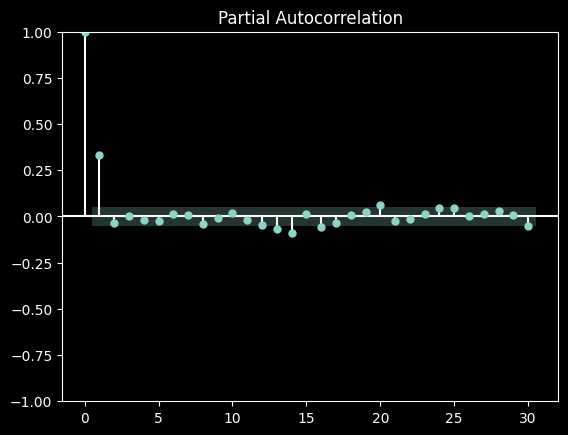

In [28]:
acf = plot_acf(df['win_res'].dropna(),lags=30)
pacf = plot_pacf(df['win_res'].dropna(),lags=30)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


rmse error:  0.8729872022987832


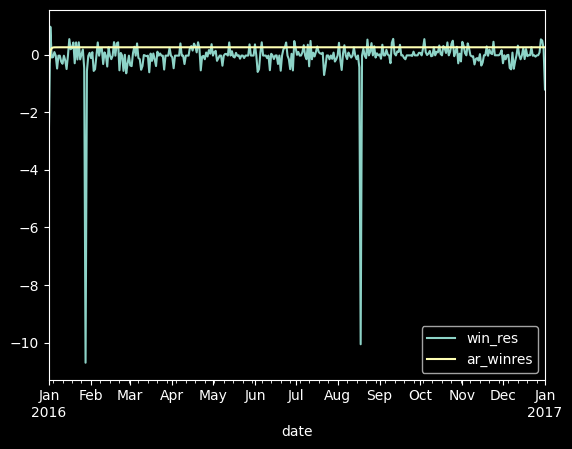

In [29]:
from statsmodels.tsa.arima.model import ARIMA
train = df[['win_res']][:datetime(2015,12,31)]
test = df[['win_res']][datetime(2016,1,1):]
model = ARIMA(train.dropna(),order=(1,0,1)).fit()
pred = model.predict(start=datetime(2016,1,1),end=datetime(2017,1,1))
test["ar_winres"]=pred
test[['win_res',"ar_winres"]].plot()
print("rmse error: ",rmse(test['win_res'],test['ar_winres']))

In [31]:
from statsmodels.tsa.api import VAR
from datetime import datetime,timedelta
train = df[['win_res','temp_res','hum_res']][:datetime(2015,12,31)]
test = df[['win_res','temp_res','hum_res']][datetime(2016,1,1):]
train.dropna(inplace=True)
model = VAR(train) 
lag_selection = model.select_order(maxlags=20)
print(lag_selection.summary())
optimal_lag = lag_selection.aic
print(optimal_lag)


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        8.817       8.831       6748.       8.822
1        7.246      7.302*       1403.       7.267
2        7.214       7.311       1358.      7.251*
3        7.230       7.369       1380.       7.282
4        7.196       7.377       1334.       7.264
5       7.193*       7.415      1330.*       7.277
6        7.197       7.462       1336.       7.297
7        7.200       7.506       1340.       7.316
8        7.195       7.542       1332.       7.326
9        7.199       7.588       1338.       7.346
10       7.198       7.629       1337.       7.361
11       7.209       7.681       1351.       7.388
12       7.205       7.719       1346.       7.399
13       7.209       7.765       1352.       7.420
14       7.214       7.811       1358.       7.440
15       7.208       7.847       1350.       7.450
16       7.214       7.895     

In [33]:
test_df = df[datetime(2016,1,1):].copy()

rmse error:  0.7801777224597882


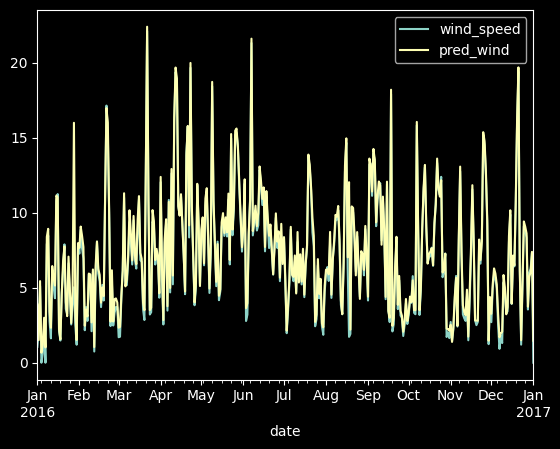

In [34]:
results = model.fit(optimal_lag)
f_input = train.iloc[-optimal_lag:].to_numpy()
forecast_values = results.forecast(f_input, steps=367)
test_df['var_win'] = forecast_values[:,0]
test_df['var_temp'] = forecast_values[:,1]
test_df['var_hum'] = forecast_values[:,2]
test_df['pred_temp'] = test_df['temp_sea']+test_df['temp_tr']+test_df['var_temp']
test_df['pred_wind'] = test_df['win_sea']+test_df['win_tr']+test_df['var_win']
test_df[['wind_speed','pred_wind']].plot()
print("rmse error: ",mean_squared_error(test_df['wind_speed'],test_df['pred_wind']))


<Axes: xlabel='date'>

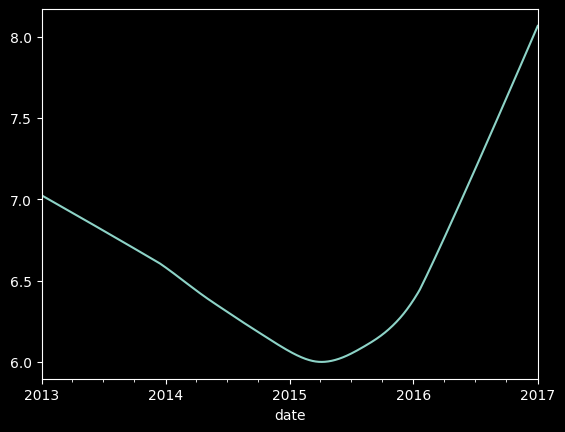

In [35]:
df['win_tr'].plot()

In [51]:
train_data = pd.read_csv(r"./DailyDelhiClimateTrain.csv")
train_data['date'] = pd.to_datetime(train_data['date'], format='%Y-%m-%d')
train_data.set_index('date',inplace=True)
train_data.sort_index(inplace=True)
test_data = pd.read_csv(r"./DailyDelhiClimateTest.csv")
test_data['date'] = pd.to_datetime(test_data['date'], format='%Y-%m-%d')
test_data.set_index('date',inplace=True)
test_data.sort_index(inplace=True)
test_data.head()
full_df = pd.concat([train_data,test_data],axis=0)
stl = STL(full_df['wind_speed'],period=365, robust=True)
res = stl.fit()
full_df['win_tr'] = res.trend

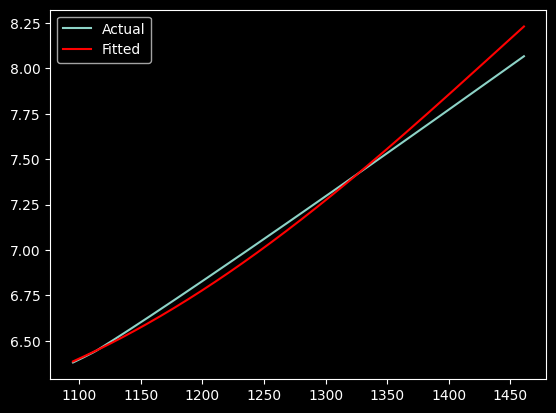

In [76]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
df['time'] = np.arange(len(df))
train_wintr = df[['win_tr','time']][:datetime(2015,12,31)]
test_wintr = df[['win_tr','time']][datetime(2016,1,1):]
X = train_wintr[['time']]
y = train_wintr['win_tr']
poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)
x_test = test_wintr[['time']]
x_test_poly = poly.fit_transform(x_test)
y_pred = model.predict(x_test_poly)
plt.plot(test_wintr['time'], test_wintr['win_tr'], label="Actual")
plt.plot(test_wintr['time'], y_pred, label="Fitted", color="red")
test_df['pred_wintr']= y_pred
plt.legend()
plt.show()


<Axes: xlabel='date'>

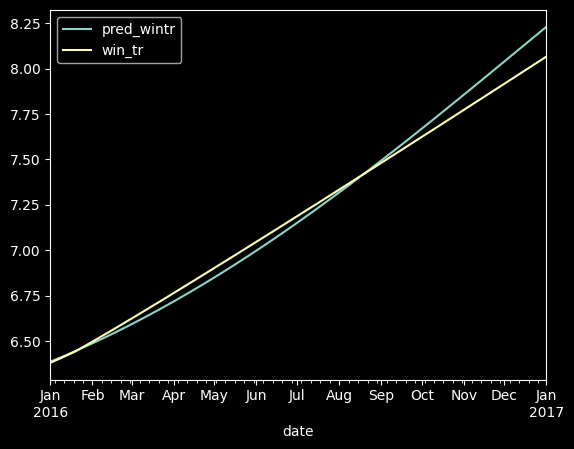

In [111]:
from numpy.polynomial.polynomial import Polynomial
x = np.arange(len(train))
p = Polynomial.fit(x,df['win_tr'][:datetime(2015,12,31)],deg=5)
pred = p(np.arange(len(train),len(df)))
test_df['pred_wintr']=pred
test_df[['pred_wintr','win_tr']].plot()


In [92]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
seasonal = df['win_sea'][:datetime(2015,12,31)]
seasonal_model = ExponentialSmoothing(seasonal, seasonal='add', seasonal_periods=365)
seasonal_fit = seasonal_model.fit()
forecasted_seasonality = seasonal_fit.forecast(367)
test_df['pred_winsea'] = forecasted_seasonality

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [100]:
seasonal_pattern = df['win_sea'][:datetime(2015,12,31)][-365:].values
forecasted_seasonality = np.tile(seasonal_pattern, int(np.ceil(367 / len(seasonal_pattern))))[:367]
test_df['pred_winsea'] = forecasted_seasonality

mse error:  4.47215167806462
rmse error:  2.114746244367068
r2 score:  0.7206825221684541


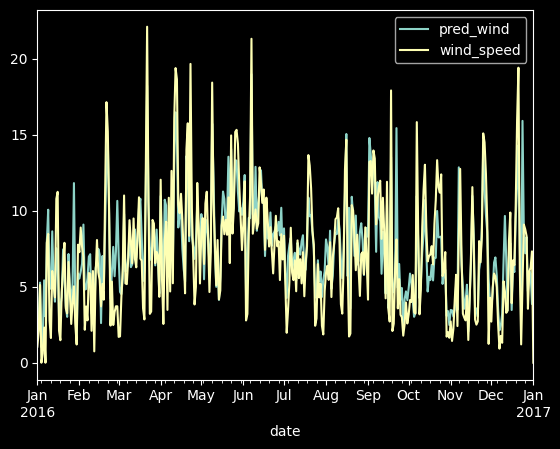

In [104]:
test_df['pred_wind']= test_df['pred_winsea']+test_df['pred_wintr']+test_df['var_win']
test_df[['pred_wind','wind_speed']].plot()
print("mse error: ",mean_squared_error(test_df['wind_speed'], test_df['pred_wind']))
print("rmse error: ",rmse(test_df['wind_speed'], test_df['pred_wind']))
print("r2 score: ",r2_score(test_df['wind_speed'], test_df['pred_wind']))

<Axes: xlabel='date'>

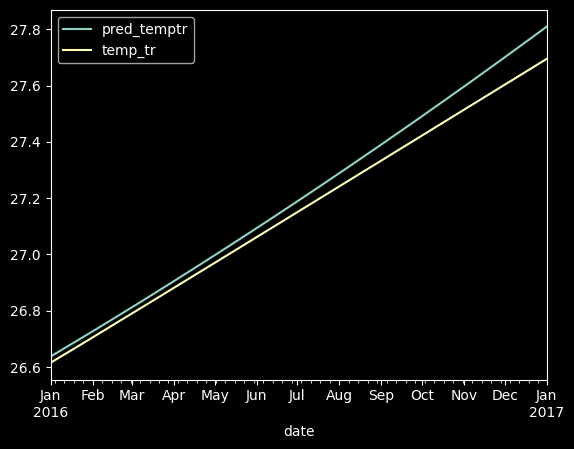

In [116]:
from numpy.polynomial.polynomial import Polynomial
x = np.arange(len(train))
p = Polynomial.fit(x,df['temp_tr'][:datetime(2015,12,31)],deg=2)
pred = p(np.arange(len(train),len(df)))
test_df['pred_temptr']=pred
test_df[['pred_temptr','temp_tr']].plot()


In [118]:
seasonal_pattern = df['temp_sea'][:datetime(2015,12,31)][-365:].values
forecasted_seasonality = np.tile(seasonal_pattern, int(np.ceil(367 / len(seasonal_pattern))))[:367]
test_df['pred_tempsea'] = forecasted_seasonality

mse error:  1.138307843723627
rmse error:  1.0669151061465139
r2 score:  0.9762789837378455


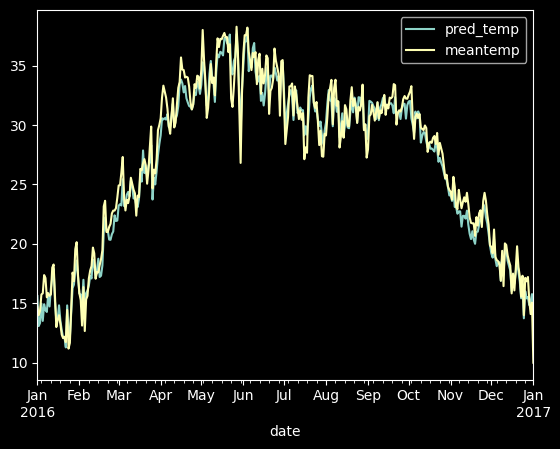

In [119]:
test_df['pred_temp']= test_df['pred_tempsea']+test_df['pred_temptr']+test_df['var_temp']
test_df[['pred_temp','meantemp']].plot()
print("mse error: ",mean_squared_error(test_df['meantemp'], test_df['pred_temp']))
print("rmse error: ",rmse(test_df['meantemp'], test_df['pred_temp']))
print("r2 score: ",r2_score(test_df['meantemp'], test_df['pred_temp']))

<Axes: xlabel='date'>

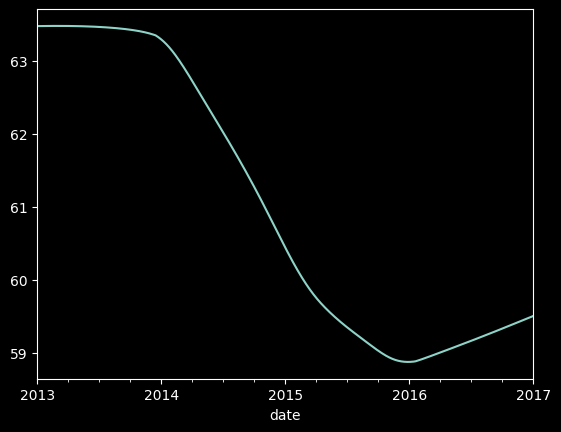

In [136]:
df['hum_tr'].plot()

<Axes: xlabel='date'>

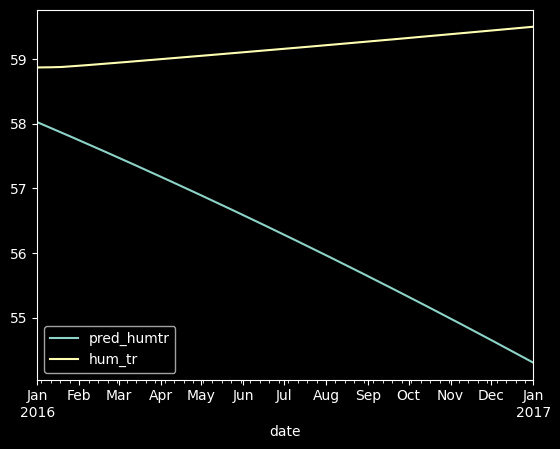

In [129]:
from numpy.polynomial.polynomial import Polynomial
x = np.arange(len(train))
p = Polynomial.fit(x,df['hum_tr'][:datetime(2015,12,31)],deg=2)
pred = p(np.arange(len(train),len(df)))
test_df['pred_humtr']=pred
test_df[['pred_humtr','hum_tr']].plot()

<Axes: xlabel='date'>

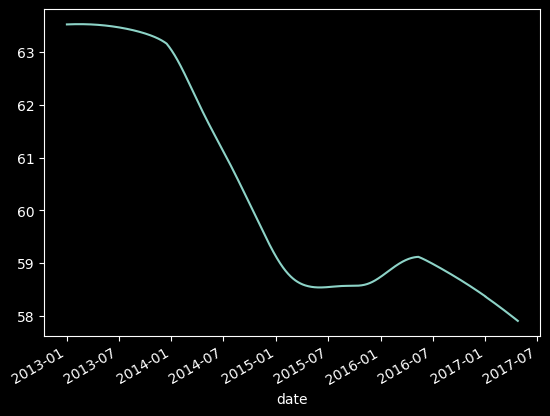

In [169]:
stl = STL(full_df['humidity'],period=365, robust=True)
res = stl.fit()
full_df['hum_tr'] = res.trend
full_df['hum_tr'].plot()

mse error:  33.828856978710256
rmse error:  5.81625798763348
r2 score:  0.8773408176234742


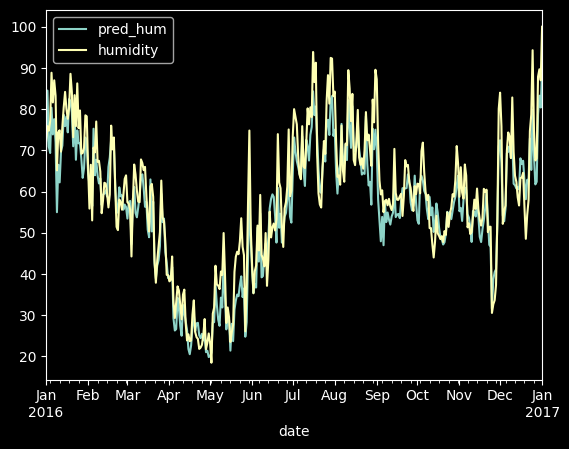

In [170]:
seasonal_pattern = df['hum_sea'][:datetime(2015,12,31)][-365:].values
forecasted_seasonality = np.tile(seasonal_pattern, int(np.ceil(367 / len(seasonal_pattern))))[:367]
test_df['pred_humsea'] = forecasted_seasonality
test_df['pred_hum']= test_df['pred_humsea']+test_df['pred_humtr']+test_df['var_hum']
test_df[['pred_hum','humidity']].plot()
print("mse error: ",mean_squared_error(test_df['humidity'], test_df['pred_hum']))
print("rmse error: ",rmse(test_df['humidity'], test_df['pred_hum']))
print("r2 score: ",r2_score(test_df['humidity'], test_df['pred_hum']))